# 03 - Garbage Classification

**Dataset:** [Garbage Dataset Classification (zlatan599)](https://www.kaggle.com/datasets/zlatan599/garbage-dataset-classification)

So sánh 3 kiến trúc CNN **độc lập với nhau**, đều lấy từ `torchvision.models` (không tự xây dựng kiến trúc từ đầu):

1. **ResNet18**
2. **EfficientNet-B0**
3. **ConvNeXt-Tiny**

EfficientNet-B0 và ConvNeXt-Tiny là các kiến trúc CNN hiện đại, hiệu quả (compound scaling, depthwise convolution, large-kernel/ModernCNN block) — phù hợp với bài toán phân loại ảnh rác thực tế, nơi hình dạng, kết cấu vật liệu và bối cảnh chụp rất đa dạng, cần mô hình vừa mạnh vừa hiệu quả về tham số hơn so với các CNN cổ điển.

Cả 3 mô hình huấn luyện **độc lập** trên cùng tập train/val/test rồi so sánh hiệu năng.

In [1]:
# ============================================================
# COMMON SETUP
# ============================================================
import os, random, time, json, copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

DEVICE: cuda


## 1. Đường dẫn dataset (local)

In [2]:
# =========================
# 1. DUONG DAN DATASET (local)
# =========================
DATA_ROOT = Path("../data/Garbage_Dataset_Classification")
IMAGES_DIR = DATA_ROOT / "images"
METADATA_CSV = DATA_ROOT / "metadata.csv"

print("DATA_ROOT exists:", DATA_ROOT.exists())
print("IMAGES_DIR exists:", IMAGES_DIR.exists())
print("METADATA_CSV exists:", METADATA_CSV.exists())

df = pd.read_csv(METADATA_CSV)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

DATA_ROOT exists: True
IMAGES_DIR exists: True
METADATA_CSV exists: True
Shape: (13901, 2)
Columns: ['filename', 'label']


,filename,label
0,cardboard_02038.jpg,cardboard
1,cardboard_02320.jpg,cardboard
2,cardboard_01728.jpg,cardboard
3,cardboard_00093.jpg,cardboard
4,cardboard_00094.jpg,cardboard


## 2. Xác định cột path/label trong metadata.csv

In [3]:
# =========================
# 2. XAC DINH COT PATH/LABEL TRONG metadata.csv
# =========================
path_col = "filename"
label_col = "label"

CLASSES = sorted(df[label_col].unique().tolist())
print("So lop:", len(CLASSES))
print("Classes:", CLASSES)
print(df[label_col].value_counts())

So lop: 6
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
label
glass        2500
trash        2500
paper        2315
plastic      2288
cardboard    2214
metal        2084
Name: count, dtype: int64


## 3. Transform + custom Dataset (đọc từ metadata.csv)

In [4]:
# =========================
# 3. TRANSFORM + CUSTOM DATASET (doc tu metadata.csv)
# =========================
from PIL import Image

IMG_SIZE = 128
BATCH_SIZE = 64

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5] * 3, [0.5] * 3)
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5] * 3, [0.5] * 3)
])

class GarbageCSVDataset(Dataset):
    def __init__(self, dataframe, images_dir, path_col, label_col, classes, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.path_col = path_col
        self.label_col = label_col
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label_name = row[self.label_col]
        img_path = self.images_dir / str(label_name) / str(row[self.path_col])
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = self.class_to_idx[label_name]
        return img, label

# full_dataset chi dung de giu .classes cho cac cell phia sau, khong train truc tiep tren no
full_dataset = GarbageCSVDataset(df, IMAGES_DIR, path_col, label_col, CLASSES, transform=eval_tf)
print("Total images:", len(full_dataset))

# Chia train/val/test theo ti le 70/15/15
n = len(df)
n_train = int(0.70 * n)
n_val = int(0.15 * n)

g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(n, generator=g).tolist()
train_idx = perm[:n_train]
val_idx   = perm[n_train:n_train + n_val]
test_idx  = perm[n_train + n_val:]

train_df = df.iloc[train_idx]
val_df   = df.iloc[val_idx]
test_df  = df.iloc[test_idx]

train_ds = GarbageCSVDataset(train_df, IMAGES_DIR, path_col, label_col, CLASSES, transform=train_tf)
val_ds   = GarbageCSVDataset(val_df,   IMAGES_DIR, path_col, label_col, CLASSES, transform=eval_tf)
test_ds  = GarbageCSVDataset(test_df,  IMAGES_DIR, path_col, label_col, CLASSES, transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

N_CLASSES = len(CLASSES)
print(len(train_ds), len(val_ds), len(test_ds))

Total images: 13901
9730 2085 2086


## 4. Xem thử dữ liệu

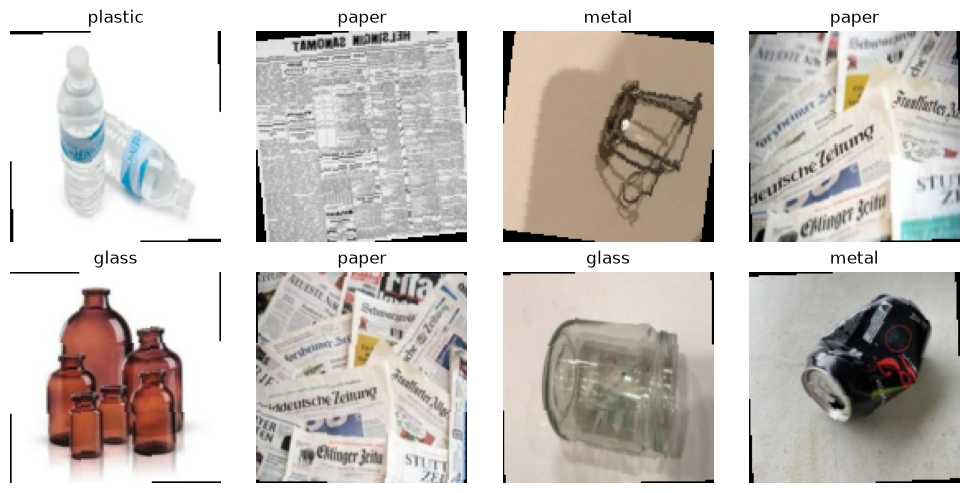

In [5]:
# =========================
# 4. VISUALIZE SAMPLE
# =========================
images, labels = next(iter(train_loader))
grid = images[:8].clone()
grid = (grid * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, img, lab in zip(axes.ravel(), grid, labels[:8]):
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(full_dataset.classes[lab])
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Định nghĩa 3 mô hình (dùng trực tiếp từ `torchvision.models`)

In [6]:
# PRETRAINED=False  -> huan luyen tu dau (random init), num_classes duoc truyen thang vao constructor.
# PRETRAINED=True   -> tai trong so ImageNet (weights="DEFAULT"), sau do THAY THE lop classifier
#                       cuoi cung de khop voi N_CLASSES (torchvision khong cho doi num_classes
#                       cung luc voi weights pretrained, vi weights pretrained co dung 1000 lop).
PRETRAINED = True


def replace_classifier_head(model, arch, n_classes):
    """Thay lop Linear cuoi cung cua model bang lop moi co dung n_classes dau ra."""
    if arch == "resnet18":
        in_f = model.fc.in_features
        model.fc = nn.Linear(in_f, n_classes)
    elif arch in ("efficientnet_b0", "convnext_tiny"):
        in_f = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_f, n_classes)
    else:
        raise ValueError(f"Unknown arch: {arch}")
    return model


def build_model(arch, n_classes, pretrained=None):
    """Tao mot mo hinh torchvision voi so lop dau ra = n_classes.
    - pretrained=False: khoi tao ngau nhien, dung thang num_classes trong constructor.
    - pretrained=True : tai weights="DEFAULT" (ImageNet) roi thay classifier head.
    - pretrained=None : lay theo bien global PRETRAINED o tren.
    """
    if pretrained is None:
        pretrained = PRETRAINED
    weights = "DEFAULT" if pretrained else None
    if not pretrained:
        if arch == "resnet18":
            return torchvision.models.resnet18(weights=None, num_classes=n_classes)
        elif arch == "efficientnet_b0":
            return torchvision.models.efficientnet_b0(weights=None, num_classes=n_classes)
        elif arch == "convnext_tiny":
            return torchvision.models.convnext_tiny(weights=None, num_classes=n_classes)
        else:
            raise ValueError(f"Unknown arch: {arch}")
    else:
        ctor = getattr(torchvision.models, arch)
        model = ctor(weights=weights)
        return replace_classifier_head(model, arch, n_classes)


MODEL_REGISTRY = {
    "ResNet18": "resnet18",
    "EfficientNet-B0": "efficientnet_b0",
    "ConvNeXt-Tiny": "convnext_tiny",
}

for name, arch in MODEL_REGISTRY.items():
    m = build_model(arch, N_CLASSES)
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{name:16s} | params: {n_params:,}")
    del m

ResNet18         | params: 11,179,590
EfficientNet-B0  | params: 4,015,234
ConvNeXt-Tiny    | params: 27,824,742


## 6. Hàm huấn luyện & đánh giá dùng chung

In [7]:
# ============================================================
# TRAIN / EVAL UTILITIES DUNG CHUNG
# ============================================================
def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        if train:
            optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        if train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(yb)
        correct += (logits.argmax(1) == yb).sum().item()
        total += len(yb)
    return total_loss / total, correct / total


def train_model(arch, name, epochs=15, lr=1e-3, weight_decay=1e-4):
    print(f"\n{'='*60}\nTraining {name}\n{'='*60}")
    model = build_model(arch, N_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_state, best_val = None, float("inf")

    t0 = time.time()
    for epoch in range(epochs):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, criterion, None)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if va_loss < best_val:
            best_val = va_loss
            best_state = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1:02d}/{epochs} | train loss={tr_loss:.4f} acc={tr_acc:.4f} "
              f"| val loss={va_loss:.4f} acc={va_acc:.4f}")

    train_time = time.time() - t0
    model.load_state_dict(best_state)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name} - training time: {train_time:.1f}s | params: {n_params:,}")

    return {"name": name, "model": model, "history": history,
            "train_time": train_time, "n_params": n_params}


@torch.no_grad()
def evaluate_model(entry, loader=test_loader):
    model = entry["model"]
    model.eval()
    preds, truths = [], []
    for xb, yb in loader:
        logits = model(xb.to(DEVICE))
        preds.extend(logits.argmax(1).cpu().numpy())
        truths.extend(yb.numpy())
    acc = accuracy_score(truths, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(truths, preds, average="macro", zero_division=0)
    return {"name": entry["name"], "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
            "preds": preds, "truths": truths}

## 7. Huấn luyện 3 mô hình 

In [8]:
EPOCHS = 15
trained = {}
for name, arch in MODEL_REGISTRY.items():
    trained[name] = train_model(arch, name, epochs=EPOCHS)


Training ResNet18
Epoch 01/15 | train loss=0.8979 acc=0.6842 | val loss=0.8422 acc=0.7209
Epoch 02/15 | train loss=0.6326 acc=0.7799 | val loss=0.6108 acc=0.7871
Epoch 03/15 | train loss=0.5143 acc=0.8223 | val loss=0.8025 acc=0.7631
Epoch 04/15 | train loss=0.5299 acc=0.8219 | val loss=0.5494 acc=0.8187
Epoch 05/15 | train loss=0.3731 acc=0.8696 | val loss=0.8716 acc=0.7472
Epoch 06/15 | train loss=0.5450 acc=0.8148 | val loss=0.4774 acc=0.8422
Epoch 07/15 | train loss=0.3788 acc=0.8673 | val loss=0.5318 acc=0.8412
Epoch 08/15 | train loss=0.3157 acc=0.8906 | val loss=0.5630 acc=0.8240
Epoch 09/15 | train loss=0.3667 acc=0.8742 | val loss=0.5661 acc=0.8187
Epoch 10/15 | train loss=0.3431 acc=0.8819 | val loss=0.5249 acc=0.8403
Epoch 11/15 | train loss=0.2150 acc=0.9266 | val loss=0.5541 acc=0.8412
Epoch 12/15 | train loss=0.4825 acc=0.8376 | val loss=0.5256 acc=0.8432
Epoch 13/15 | train loss=0.3337 acc=0.8835 | val loss=0.4731 acc=0.8561
Epoch 14/15 | train loss=0.2370 acc=0.9192 | 

## 8. So sánh hiệu năng giữa 3 mô hình

In [9]:
results = [evaluate_model(trained[name]) for name in MODEL_REGISTRY]
results_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ("preds", "truths")} for r in results])
results_df["train_time_s"] = [trained[n]["train_time"] for n in MODEL_REGISTRY]
results_df["n_params"] = [trained[n]["n_params"] for n in MODEL_REGISTRY]
results_df = results_df.sort_values("f1", ascending=False).reset_index(drop=True)
display(results_df)

best_name = results_df.iloc[0]["name"]
print(f"\n>>> Mo hinh tot nhat (theo F1-macro tren test set): {best_name}")

,name,accuracy,precision,recall,f1,train_time_s,n_params
0,EfficientNet-B0,0.920901,0.920287,0.920653,0.920191,648.039646,4015234
1,ConvNeXt-Tiny,0.891659,0.893026,0.890739,0.891188,1313.774419,27824742
2,ResNet18,0.863375,0.863011,0.863650,0.862910,745.434086,11179590



>>> Mo hinh tot nhat (theo F1-macro tren test set): EfficientNet-B0


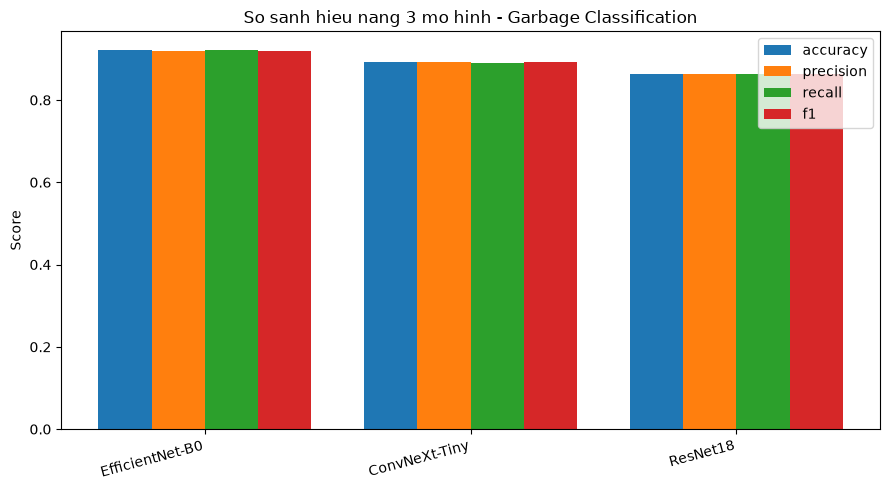

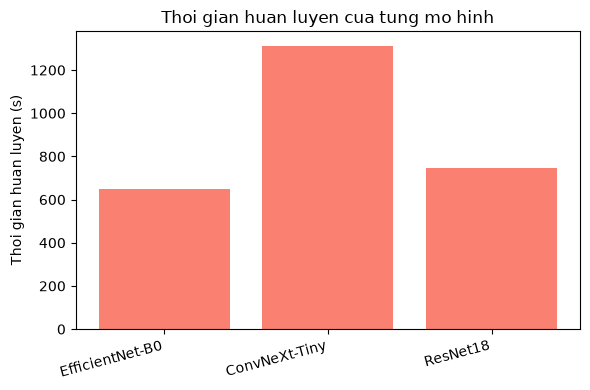

In [10]:
metrics = ["accuracy", "precision", "recall", "f1"]
x = np.arange(len(results_df))
width = 0.2

fig, ax = plt.subplots(figsize=(9, 5))
for i, m in enumerate(metrics):
    ax.bar(x + i * width, results_df[m], width, label=m)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df["name"], rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_title("So sanh hieu nang 3 mo hinh - Garbage Classification")
ax.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(results_df["name"], results_df["train_time_s"], color="salmon")
plt.ylabel("Thoi gian huan luyen (s)")
plt.title("Thoi gian huan luyen cua tung mo hinh")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


ResNet18
              precision    recall  f1-score   support

   cardboard     0.8382    0.8662    0.8520       299
       glass     0.9091    0.8719    0.8901       367
       metal     0.8197    0.8876    0.8523       338
       paper     0.8635    0.8659    0.8647       358
     plastic     0.8584    0.8410    0.8496       346
       trash     0.8892    0.8492    0.8687       378

    accuracy                         0.8634      2086
   macro avg     0.8630    0.8636    0.8629      2086
weighted avg     0.8646    0.8634    0.8636      2086



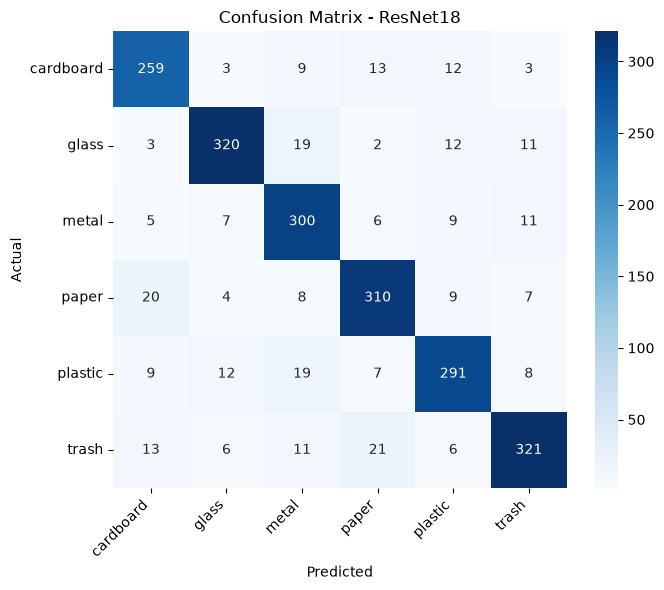


EfficientNet-B0
              precision    recall  f1-score   support

   cardboard     0.9045    0.9498    0.9266       299
       glass     0.9357    0.9510    0.9432       367
       metal     0.9377    0.8905    0.9135       338
       paper     0.9274    0.9274    0.9274       358
     plastic     0.8889    0.8555    0.8719       346
       trash     0.9276    0.9497    0.9386       378

    accuracy                         0.9209      2086
   macro avg     0.9203    0.9207    0.9202      2086
weighted avg     0.9209    0.9209    0.9206      2086



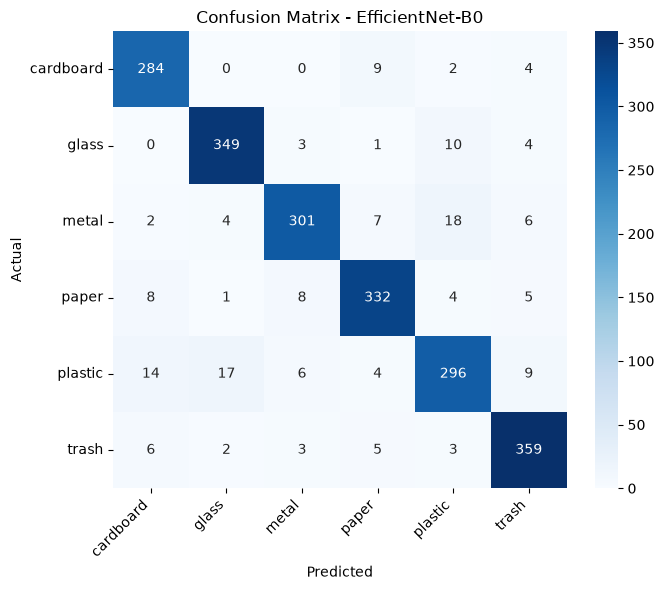


ConvNeXt-Tiny
              precision    recall  f1-score   support

   cardboard     0.8870    0.8930    0.8900       299
       glass     0.9341    0.8883    0.9106       367
       metal     0.9110    0.8787    0.8946       338
       paper     0.8946    0.8771    0.8858       358
     plastic     0.8776    0.8497    0.8634       346
       trash     0.8538    0.9577    0.9027       378

    accuracy                         0.8917      2086
   macro avg     0.8930    0.8907    0.8912      2086
weighted avg     0.8929    0.8917    0.8915      2086



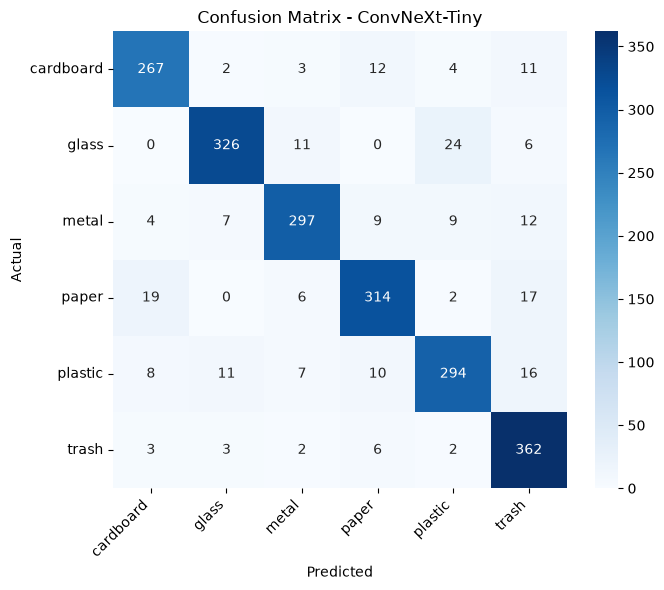

In [11]:
for r in results:
    print(f"\n{'='*60}\n{r['name']}\n{'='*60}")
    print(classification_report(r["truths"], r["preds"], target_names=CLASSES, digits=4))
    cm = confusion_matrix(r["truths"], r["preds"])
    plt.figure(figsize=(max(7, len(CLASSES) * 0.7), max(6, len(CLASSES) * 0.6)))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASSES, yticklabels=CLASSES, cmap="Blues")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {r['name']}")
    plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

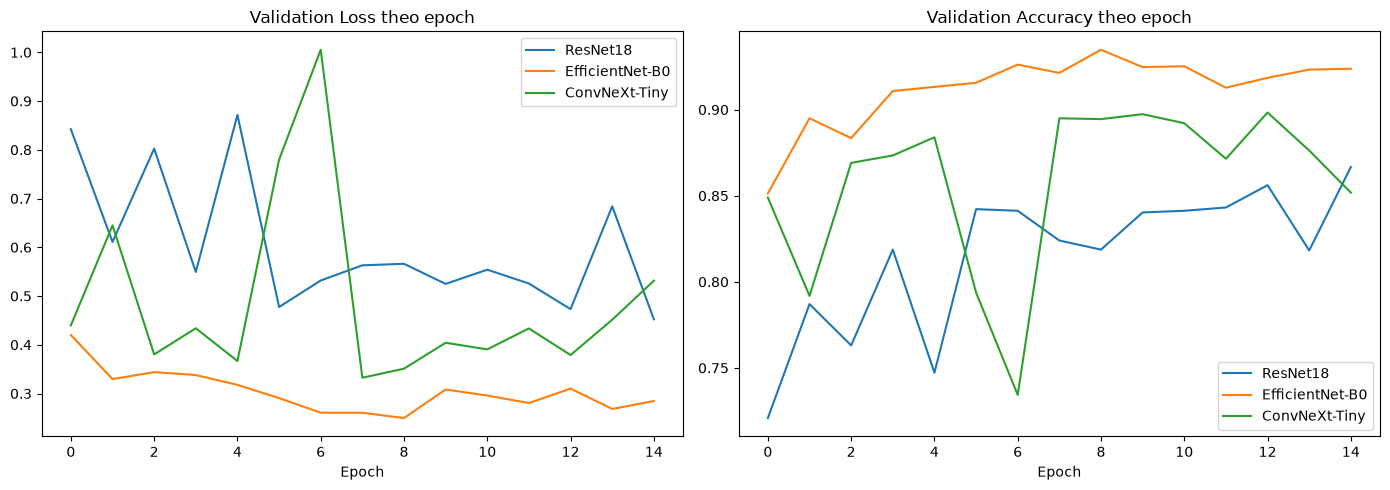

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name in MODEL_REGISTRY:
    h = trained[name]["history"]
    axes[0].plot(h["val_loss"], label=name)
    axes[1].plot(h["val_acc"], label=name)
axes[0].set_title("Validation Loss theo epoch"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].set_title("Validation Accuracy theo epoch"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.show()

## 9. Kết luận

Bảng `results_df` xếp hạng 3 mô hình theo **F1-macro** trên tập test. ConvNeXt-Tiny và EfficientNet-B0 thường cho độ chính xác cao nhờ kiến trúc hiện đại, nhưng cũng phức tạp và tốn tài nguyên huấn luyện hơn ResNet18. Nên đối chiếu cả 3 tiêu chí: accuracy/F1, thời gian huấn luyện, và số tham số (`n_params`) để chọn mô hình phù hợp nhất với mục tiêu triển khai thực tế (ví dụ mô hình nhẹ hơn nếu cần chạy trên thiết bị hạn chế tài nguyên).